# 7. Extra Utilities

## Tool: Restore Run State to Tune Configs

This tool restores **values only** from a saved run into a target tune while preserving file structure.

Notebook usage pattern:
- Set parameters and toggles in the single code cell below.
- Set `RUN_RESTORE=False` to preview changes (dry-run).
- Set `RUN_RESTORE=True` to apply changes.

CLI equivalents:
```bash
# Dry-run
python scripts/restore_run_state.py \
  --from-run cells/SST/tunes/seg_tuned/output_data/_final_base_SST/results \
  --to-tune cells/SST/tunes/seg_tuned \
  --apply sim_config,cell_config,geometry,syn_config,syn_groups \
  --syn-groups all

# Write changes
python scripts/restore_run_state.py \
  --from-run cells/SST/tunes/seg_tuned/output_data/_final_base_SST/results \
  --to-tune cells/SST/tunes/seg_tuned \
  --apply sim_config,syn_config,syn_groups,fit_json \
  --syn-groups pn_exc,bg_exc \
  --write
```

This notebook layout will be reused for future extra tools.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.restore_run_state import restore_run_state, print_report

# -------- Execution gate --------
# False -> dry-run preview, True -> apply changes
RUN_RESTORE = False

# -------- Inputs --------
from_run = Path('/home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/output_data/SST4.0_tuned_2000')
to_tune = Path('/home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all')
apply = ['fit_json', 'cell_config', 'geometry', 'syn_config', 'syn_groups']
# Optional: add 'fit_json' to apply list
syn_groups = 'all'  # or e.g. 'pn_exc,bg_exc,vip_inh'
allow_source_fallback = True 
backup = True

# -------- Execute --------
report = restore_run_state(
    from_run=from_run,
    to_tune=to_tune,
    apply=apply,
    syn_groups=syn_groups,
    dry_run=not RUN_RESTORE,
    allow_source_fallback=allow_source_fallback,
    backup=backup,
)
print_report(report)


[restore_run_state] Mode: DRY-RUN
[restore_run_state] Source run: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/output_data/SST4.0_tuned_2000/results
[restore_run_state] Target tune: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all
[restore_run_state] Apply: cell_config, fit_json, geometry, syn_config, syn_groups
[restore_run_state] Syn groups: all

[warning] Using source-tune fallback for cell_config: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/cell_configs/cell_config.json
[warning] Using source-tune fallback for geometry: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/cell_configs/geometry.json

[unchanged] cell_config: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/cell_configs/cell_config.json (No value differences on matching keys.)
[unchanged] geometry: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/cell_configs/geometry.json (No value differences on matching keys.)
[unchanged] syn_config: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/cell_configs/syn_config.json (No value di

## Tool: Export Spikes CSV

Export `spikes.npz` to one CSV row per trial.

CLI equivalents:
```bash
# Direct CLI export:
python scripts/export_spikes_csv.py \
  --input cells/PV/tunes/seg_tuned/output_data/_active_base_PV \
  --delimiter "," \
  --precision 10 \
  --trial-prefix trial_

# Add --overwrite to replace an existing CSV
```


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules_local.analysis import analysis

# -------- Execution gate --------
# False -> dry-run preview, True -> export CSV
RUN_EXPORT_SPIKES = False

# -------- Inputs --------
# Set to either: run folder OR direct spikes.npz path
spikes_source = Path('cells/SST/tunes/seg_tuned_all/output_data/SST2.6_tuned2')
spikes_csv_out = None  # e.g. Path('cells/PV/tunes/seg_tuned/output_data/_active_base_PV/results/my_spikes_trials.csv')
spikes_time_delimiter = ','
spikes_precision = 10
spikes_trial_prefix = 'trial_'
spikes_overwrite = False

# -------- Resolve source / dry-run preview --------
source = Path(spikes_source)
if source.is_dir():
    candidate = source / 'results' / 'spikes.npz'
    if not candidate.is_file():
        candidate = source / 'spikes.npz'
else:
    candidate = source

if not candidate.is_file():
    raise FileNotFoundError(f'Could not find spikes.npz from source: {source}')

default_out = candidate.with_name('spikes_trials.csv')
resolved_out = Path(spikes_csv_out) if spikes_csv_out is not None else default_out

if not RUN_EXPORT_SPIKES:
    print('[dry-run] Would export spikes CSV with:')
    print(f'  source spikes: {candidate}')
    print(f'  out csv      : {resolved_out}')
    print(f'  delimiter    : {spikes_time_delimiter!r}')
    print(f'  precision    : {spikes_precision}')
    print(f'  trial_prefix : {spikes_trial_prefix!r}')
    print(f'  overwrite    : {spikes_overwrite}')
else:
    out_csv = analysis.export_spikes_trials_csv(
        source,
        out_csv=spikes_csv_out,
        delimiter=spikes_time_delimiter,
        precision=spikes_precision,
        overwrite=spikes_overwrite,
        trial_prefix=spikes_trial_prefix,
    )
    print(f'Saved spikes trial CSV: {out_csv}')


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


Saved spikes trial CSV: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all/output_data/SST2.6_tuned2/results/spikes_trials.csv


--No graphics will be displayed.


## Tool: Merge Two Outputs

Merge two run outputs into one multi-trial run with a **config-first safety gate**.

Output layout on write:
- `<output_dir>/<output_stem>/results/...`
- `<output_dir>/<output_stem>/logs/merge_<timestamp>/...` (default; disable with `--no-logs`)

Policy implemented:
- Config differences are the primary compatibility check.
- Dynamic differences (seed/input variability) are only treated as important when both runs are expected to be deterministic from `sim_config`.

CLI equivalents:

```bash
# Dry-run (default)
python scripts/merge_two_runs.py \
  --run-a cells/SST/tunes/seg_tuned/output_data/_active_base_SST \
  --run-b cells/SST/tunes/seg_tuned/output_data/_active_tuned_SST

# Write merged run
python scripts/merge_two_runs.py \
  --run-a cells/SST/tunes/seg_tuned/output_data/_active_base_SST \
  --run-b cells/SST/tunes/seg_tuned/output_data/_active_tuned_SST \
  --output-dir cells/SST/tunes/seg_tuned/output_data \
  --output-stem merged_active_runs \
  --write

# Write without logs folder
python scripts/merge_two_runs.py \
  --run-a cells/SST/tunes/seg_tuned/output_data/_active_base_SST \
  --run-b cells/SST/tunes/seg_tuned/output_data/_active_tuned_SST \
  --output-stem merged_active_runs \
  --write --no-logs
```


save_plots single_plot warning: Top input panel: group list empty, auto-using all groups (5).
[merge_two_runs] Mode: WRITE
[merge_two_runs] run_a: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned/results
[merge_two_runs] run_b: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned2/results
[merge_two_runs] output_dir: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data
[merge_two_runs] output_stem: PV4.0_tuned_4000
[merge_two_runs] output_run_dir: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned_4000
[merge_two_runs] results_dir: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned_4000/results
[merge_two_runs] trial counts: run_a=2000, run_b=2000, merged=4000

[merge_two_runs] deterministic_equivalence_expected: False
  - run_a: randomness_mode=random.
  - run_b: randomness_mode=random.

[warning] Randomness settings indicate stochastic variation; seed/input differences are treated as expected.
[warning] [run_a] Using source

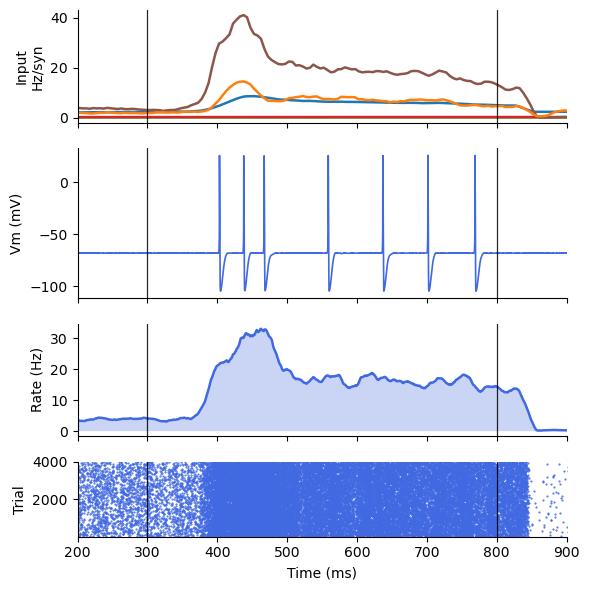

In [ ]:
from pathlib import Path

import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.merge_two_runs import merge_two_runs, print_report

# -------- Execution gate --------
# False -> dry-run preview, True -> merge and write output
RUN_MERGE = False

# -------- Inputs --------
run_a = Path('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned')
run_b = Path('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/PV4.0_tuned2')
output_dir = Path('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data')
output_stem = 'PV4.0_tuned_4000'  # run folder name under output_dir
strict_configs = True
keep_logs = True
max_diffs = 200

# -------- Execute --------
report = merge_two_runs(
    run_a=run_a,
    run_b=run_b,
    output_dir=output_dir,
    output_stem=output_stem,
    dry_run=not RUN_MERGE,
    strict_configs=strict_configs,
    keep_logs=keep_logs,
    max_diffs=max_diffs,
)
print_report(report)


## Tool: Clear `slurm_*` Runs

Delete top-level runs in a tune's `output_data` whose names start with `slurm_`.

Default mode is dry-run.

CLI equivalents:
```bash
# Dry-run
python scripts/clear_slurm_runs.py \
  --tune-dir cells/SST/tunes/seg_tuned_all

# Delete matching entries
python scripts/clear_slurm_runs.py \
  --tune-dir cells/SST/tunes/seg_tuned_all \
  --write
```


In [ ]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.clear_slurm_runs import clear_slurm_runs, print_report

# -------- Execution gate --------
# False -> dry-run preview, True -> delete matching runs
RUN_CLEAR_SLURM = False 

# -------- Inputs --------
tune_dir = Path('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned')
output_data_dir = None  # optional direct override to output_data path
slurm_prefix = 'slurm_'
max_items_to_show = 120

# -------- Execute --------
report = clear_slurm_runs(
    tune_dir=tune_dir if output_data_dir is None else None,
    output_data_dir=output_data_dir,
    prefix=slurm_prefix,
    dry_run=not RUN_CLEAR_SLURM,
)
print_report(report, max_items=max_items_to_show)


[clear_slurm_runs] Mode: WRITE
[clear_slurm_runs] output_data_dir: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data
[clear_slurm_runs] prefix: 'slurm_'
[clear_slurm_runs] matches: 26

[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43228
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43279
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43330
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43381
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43483
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43534
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43611
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43662
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43713
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data/slurm_43764
[removed] /home/hrbncv/SCP/cells/PV/tunes/seg_tuned